# Educational Knowledge Graph Project

### Building Structured Knowledge from Unstructured Data

**Group:** Group 7  
**Instructor:** Jiaxin Du

In [1]:
!python -m pip install networkx matplotlib scikit-learn pandas

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 11.5 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.3 MB 15.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 15.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 13.9 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.1 MB 16.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.7 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.9 MB 13.3 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 13.2 MB/s eta 0:00:01
   ------------------------------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Owner\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [1]:
import os

# set matplotlib config path here so it does not cause issues
os.environ["MPLCONFIGDIR"] = os.path.abspath("./mplconfig")

# display plots in the notebook
%matplotlib inline

import re
import itertools
from collections import Counter

import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

Matplotlib is building the font cache; this may take a moment.


In [2]:
# folder where the text files are stored
data_folder = "data"

documents = []

# go through each file in the folder
for file_name in os.listdir(data_folder):
    if file_name.endswith(".txt"):
        with open(os.path.join(data_folder, file_name), "r", encoding="utf-8") as f:
            documents.append(f.read())

# quick check to see how many documents were loaded
print("Number of documents loaded:", len(documents))

# preview a few documents (just first 150 characters)
for i, doc in enumerate(documents, 1):
    print(f"\nDocument {i} preview:")
    print(doc[:150])

Number of documents loaded: 5

Document 1 preview:
Computer Science

Computer science is the study of computation, information, and automation. It focuses on how computers process data, solve problems,

Document 2 preview:
Cybersecurity

Cybersecurity (also known as computer security or IT security) is the practice of protecting computer systems, networks, and data from 

Document 3 preview:
Data Science

Data science is an interdisciplinary field that focuses on extracting useful knowledge and insights from data. It combines techniques fr

Document 4 preview:
Health Informatics

Health informatics is the use of computer science and information technology to improve healthcare systems. It focuses on managing

Document 5 preview:
Machine Learning

Machine learning is a branch of artificial intelligence that focuses on creating systems that can learn from data and improve their 


In [3]:
# function to clean the text
def clean_text(text):
    text = text.lower()  # convert everything to lowercase
    text = re.sub(r"[^a-zA-Z0-9\s.]", "", text)  # remove symbols/punctuation
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

# apply cleaning to all documents
cleaned_docs = [clean_text(doc) for doc in documents]

# quick check
print("Cleaned first document:")
print(cleaned_docs[0])

Cleaned first document:
computer science computer science is the study of computation information and automation. it focuses on how computers process data solve problems and perform tasks efficiently. the field includes both theoretical concepts and practical applications such as designing software and building computer systems. key concepts in computer science computer science is built on several core ideas algorithms which are stepbystep procedures for solving problems data structures which organize and store data efficiently computation theory which studies what problems can be solved by computers programming which involves writing instructions for computers these concepts form the foundation for developing software and systems. major areas of computer science computer science includes many specialized areas such as artificial intelligence which focuses on building systems that can learn and make decisions software engineering which deals with designing and maintaining software comp

In [4]:
# split documents into smaller sentences
sentences = []

for doc in cleaned_docs:
    parts = doc.split(".")  # split using period
    for s in parts:
        s = s.strip()
        if s:
            sentences.append(s)

# check how many sentences we got
print("Number of sentences:", len(sentences))

# preview first few sentences
print("\nFirst 5 sentences:")
for s in sentences[:5]:
    print("-", s)

Number of sentences: 76

First 5 sentences:
- computer science computer science is the study of computation information and automation
- it focuses on how computers process data solve problems and perform tasks efficiently
- the field includes both theoretical concepts and practical applications such as designing software and building computer systems
- key concepts in computer science computer science is built on several core ideas algorithms which are stepbystep procedures for solving problems data structures which organize and store data efficiently computation theory which studies what problems can be solved by computers programming which involves writing instructions for computers these concepts form the foundation for developing software and systems
- major areas of computer science computer science includes many specialized areas such as artificial intelligence which focuses on building systems that can learn and make decisions software engineering which deals with designing and

In [5]:
# use TF-IDF to extract important phrases (bigrams)
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(2, 2),  # looking at word pairs
    max_features=30
)

X = vectorizer.fit_transform(cleaned_docs)
concepts = vectorizer.get_feature_names_out()

# see what was extracted
print("Extracted concepts:")
print(concepts)

Extracted concepts:
['analyze data' 'artificial intelligence' 'computer science'
 'cybersecurity cybersecurity' 'data science' 'ethical concerns'
 'health informatics' 'healthcare systems' 'informatics health'
 'key concepts' 'large datasets' 'learning machine' 'machine learning'
 'make predictions' 'new data' 'patient data' 'process data' 'role modern'
 'science computer' 'science data' 'sensitive information'
 'solve problems' 'solving problems' 'systems common' 'systems data'
 'systems vulnerabilities' 'technologies like' 'trained using'
 'training data' 'used realworld']


In [6]:
# count how often concepts appear together in the same sentence
edge_counter = Counter()

for sentence in sentences:
    present = []

    # check which concepts are in this sentence
    for concept in concepts:
        if concept in sentence:
            present.append(concept)

    # remove duplicates
    present = list(set(present))

    # create pairs of concepts and count them
    for a, b in itertools.combinations(sorted(present), 2):
        edge_counter[(a, b)] += 1

# show top relationships
print("Top relationships:")
for edge, weight in edge_counter.most_common(10):
    print(edge, "->", weight)

Top relationships:
('computer science', 'science computer') -> 4
('health informatics', 'informatics health') -> 4
('artificial intelligence', 'machine learning') -> 3
('data science', 'science data') -> 3
('health informatics', 'patient data') -> 3
('learning machine', 'machine learning') -> 3
('computer science', 'solving problems') -> 2
('artificial intelligence', 'computer science') -> 2
('artificial intelligence', 'science computer') -> 2
('computer science', 'data science') -> 2


In [7]:
# create the graph
G = nx.Graph()

# add all concepts as nodes
for concept in concepts:
    G.add_node(concept)

# add edges based on how often concepts appear together
for (a, b), weight in edge_counter.items():
    if weight >= 2:  # skip weak connections
        G.add_edge(a, b, weight=weight)

# connect any isolated nodes to the main concept
main_concept = "machine learning"  # can change this if needed

for node in list(G.nodes()):
    if G.degree(node) == 0 and node != main_concept:
        G.add_edge(node, main_concept, weight=1)

# quick check
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 30
Edges: 29


In [8]:
# fix some phrases that came out reversed
fix_map = {
    "science computer": "computer science",
    "informatics health": "health informatics",
    "learning machine": "machine learning",
    "science data": "data science"
}

# remove phrases that are not really useful
bad_terms = {
    "key concepts",
    "process data",
    "solve problems",
    "make predictions",
    "systems data",
    "new data",
    "analyze data",
    "technologies like",
    "sensitive information",
    "multidisciplinary field",
    "models used",
    "trained using",
    "role modern",
    "systems common",
    "nature data",
    "used realworld",
    "models make"
}

# apply fixes
concepts = [fix_map.get(c, c) for c in concepts]

# remove unwanted terms
concepts = [c for c in concepts if c not in bad_terms]

# remove duplicates while keeping order
concepts = list(dict.fromkeys(concepts))

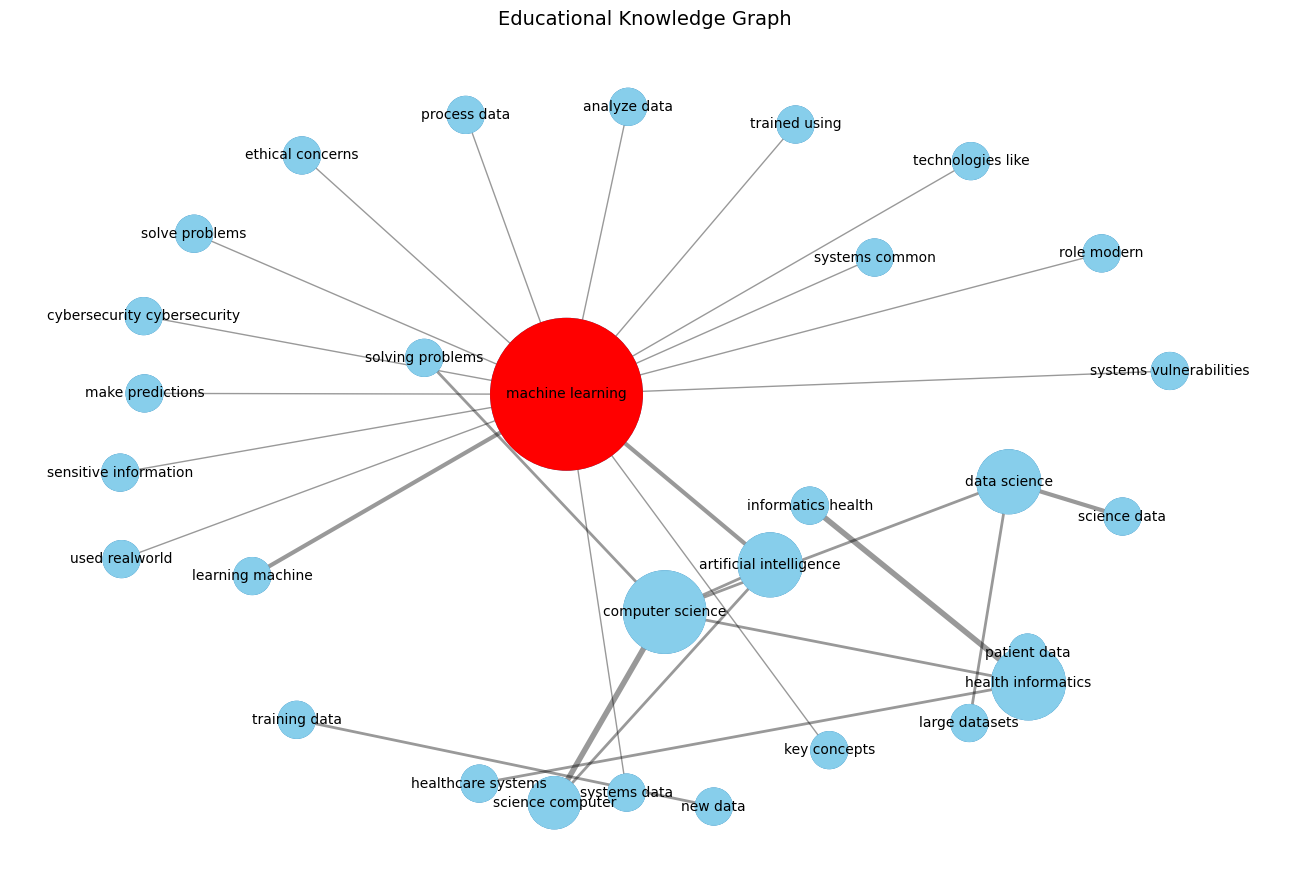

In [9]:
# set figure size for better visibility
plt.figure(figsize=(13, 9))

# generate layout for positioning nodes
pos = nx.spring_layout(G, k=1.5, seed=42)

# get number of connections for each node
degree = dict(G.degree())

# draw nodes (size based on how connected they are)
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[max(degree[node], 1) * 700 for node in G.nodes()],
    node_shape="o"
)

# highlight the main concept differently
node_colors = [
    "red" if node == "machine learning" else "skyblue"
    for node in G.nodes()
]

# draw nodes again with colors applied
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[max(degree[node], 1) * 700 for node in G.nodes()],
    node_color=node_colors
)

# draw edges (connections between concepts)
nx.draw_networkx_edges(
    G,
    pos,
    width=[G[u][v]["weight"] for u, v in G.edges()],
    alpha=0.4
)

# add labels to nodes
nx.draw_networkx_labels(G, pos, font_size=10)

# add title and clean up axes
plt.title("Educational Knowledge Graph", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()

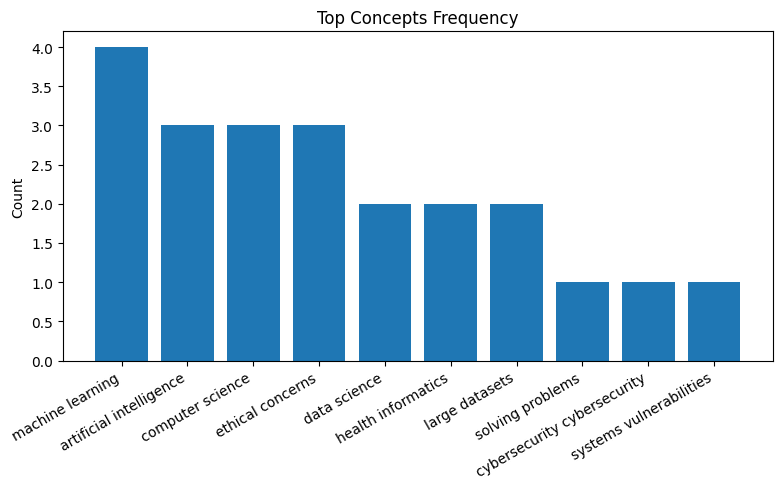

In [10]:
# count how often each concept appears across documents
concept_counts = Counter()

for doc in cleaned_docs:
    for concept in concepts:
        if concept in doc:
            concept_counts[concept] += 1

# get top 10 most frequent concepts
top_concepts = concept_counts.most_common(10)

# separate labels and values for plotting
labels = [item[0] for item in top_concepts]
values = [item[1] for item in top_concepts]

# draw bar chart
plt.figure(figsize=(8, 5))
plt.bar(labels, values)

# rotate labels for better readability
plt.xticks(rotation=30, ha="right")

plt.title("Top Concepts Frequency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

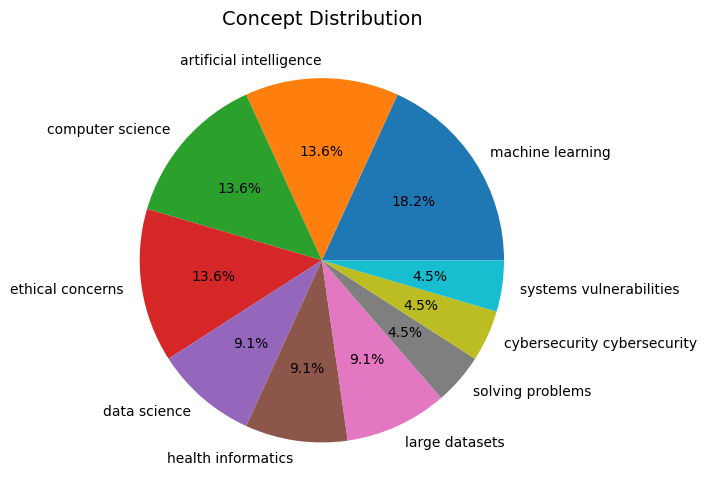

In [11]:
# draw pie chart to show concept distribution
plt.figure(figsize=(7, 7))

plt.pie(values, labels=labels, autopct="%1.1f%%")

# add title
plt.title("Concept Distribution", fontsize=14)

plt.tight_layout()
plt.show()